# Customer personality analysis

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

iris = load_iris(as_frame=True)
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## Nettoyage du dataset (doublons, valeurs aberrantes, etc.)

In [2]:
db = iris.frame

print(f"Dimensions du dataset brut : {db.shape}")

# Suppression des doublons
n_before = len(db)
db = db.drop_duplicates()
print(f"Doublons supprimés : {n_before - len(db)}")

# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(db.isnull().sum())

print("\nAperçu des premières lignes :")
print(db.head())

Dimensions du dataset brut : (150, 5)
Doublons supprimés : 1

Valeurs manquantes par colonne :
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Aperçu des premières lignes :
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


## Pré-traitement des données (normalisation, encodage, etc.)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Séparation variables / cible
features = [col for col in db.columns if col != "target"]
X = db[features]

# Standardisation (moyenne=0, écart-type=1), requis pour K-Means (distance euclidienne sensible aux échelles)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features, index=X.index)

print("Statistiques AVANT normalisation :")
print(X.describe().round(2))
print("\nStatistiques APRÈS normalisation :")
print(X_scaled.describe().round(2))

Statistiques AVANT normalisation :
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             149.00            149.00             149.00   
mean                5.84              3.06               3.75   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.30   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  
count            149.00  
mean               1.19  
std                0.76  
min                0.10  
25%                0.30  
50%                1.30  
75%                1.80  
max                2.50  

Statistiques APRÈS normalisation :
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             149.00            149.00  

## Analyse descriptive et exploratoire générale des données

In [4]:
print("=== Statistiques descriptives ===")
print(db.describe().round(2))
print(f"\nDistribution des classes (0=setosa, 1=versicolor, 2=virginica) :")
print(db["target"].value_counts().sort_index())

=== Statistiques descriptives ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             149.00            149.00             149.00   
mean                5.84              3.06               3.75   
std                 0.83              0.44               1.77   
min                 4.30              2.00               1.00   
25%                 5.10              2.80               1.60   
50%                 5.80              3.00               4.30   
75%                 6.40              3.30               5.10   
max                 7.90              4.40               6.90   

       petal width (cm)  target  
count            149.00  149.00  
mean               1.19    0.99  
std                0.76    0.82  
min                0.10    0.00  
25%                0.30    0.00  
50%                1.30    1.00  
75%                1.80    2.00  
max                2.50    2.00  

Distribution des classes (0=setosa, 1=versicolor, 2=virginica) :
target
0

### Distribution des variables

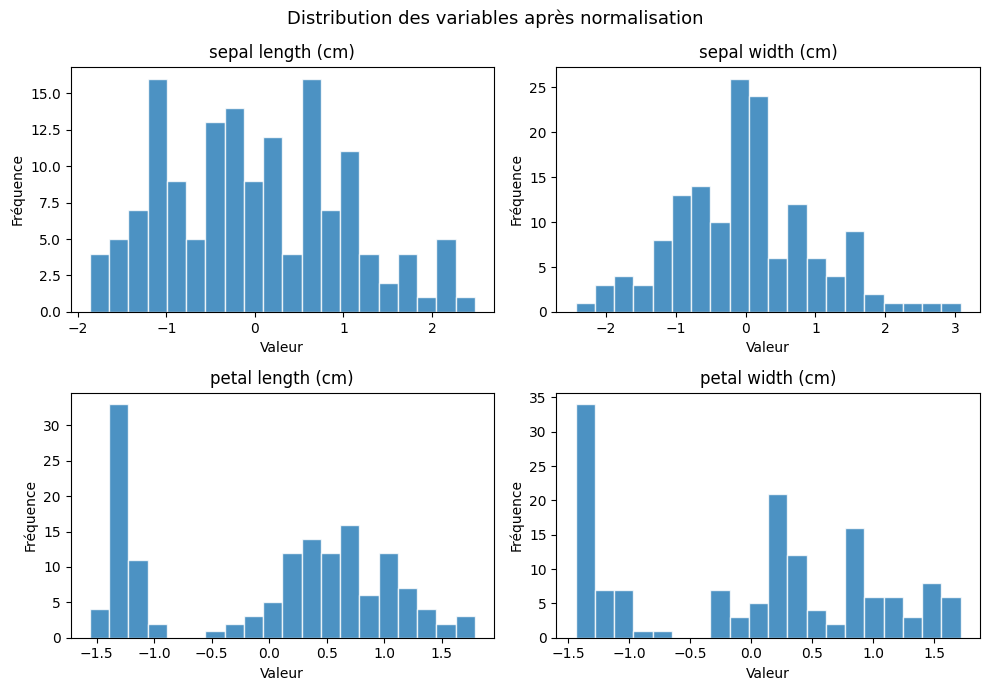

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(X_scaled[col], bins=20, edgecolor="white", alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("Valeur")
    axes[i].set_ylabel("Fréquence")

plt.suptitle("Distribution des variables après normalisation", fontsize=13)
plt.tight_layout()
plt.show()

### Matrice de corrélation des variables

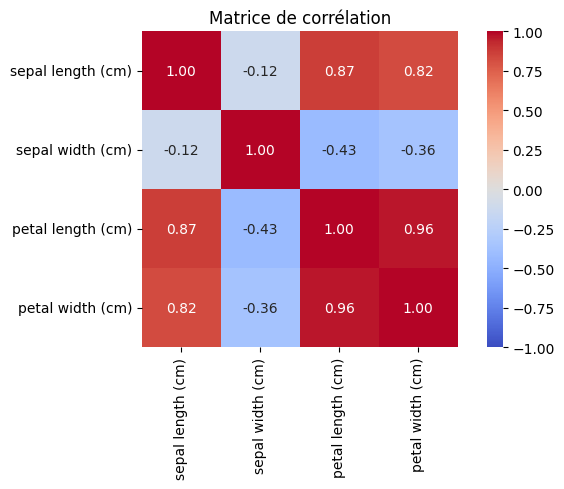

In [10]:
corr = X.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

### Pairplot : relations entre variables par espèce

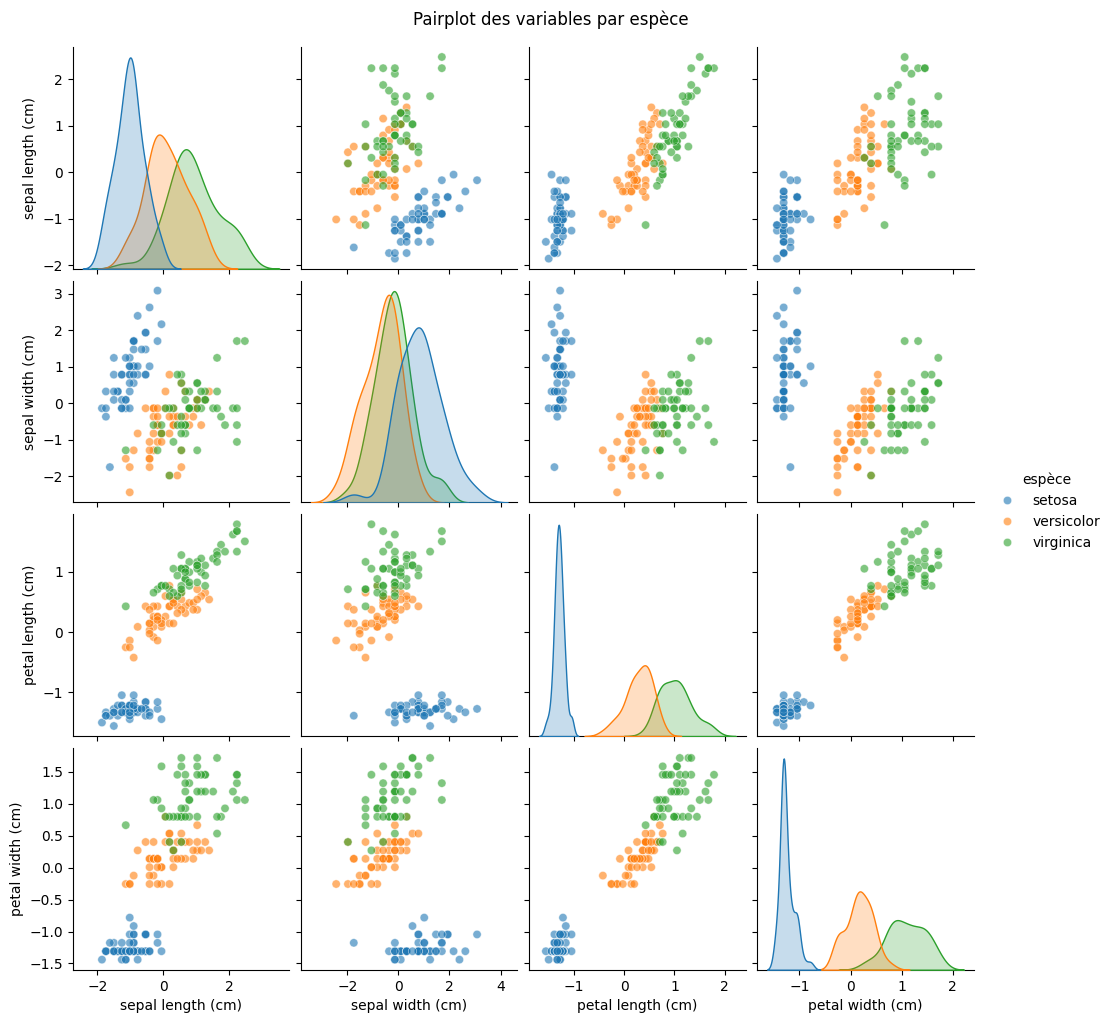

In [11]:
species_names = {0: "setosa", 1: "versicolor", 2: "virginica"}
plot_df = X_scaled.copy()
plot_df["espèce"] = db["target"].map(species_names)

sns.pairplot(plot_df, hue="espèce", diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Pairplot des variables par espèce", y=1.02)
plt.show()